In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/retail_sales_dataset.csv")

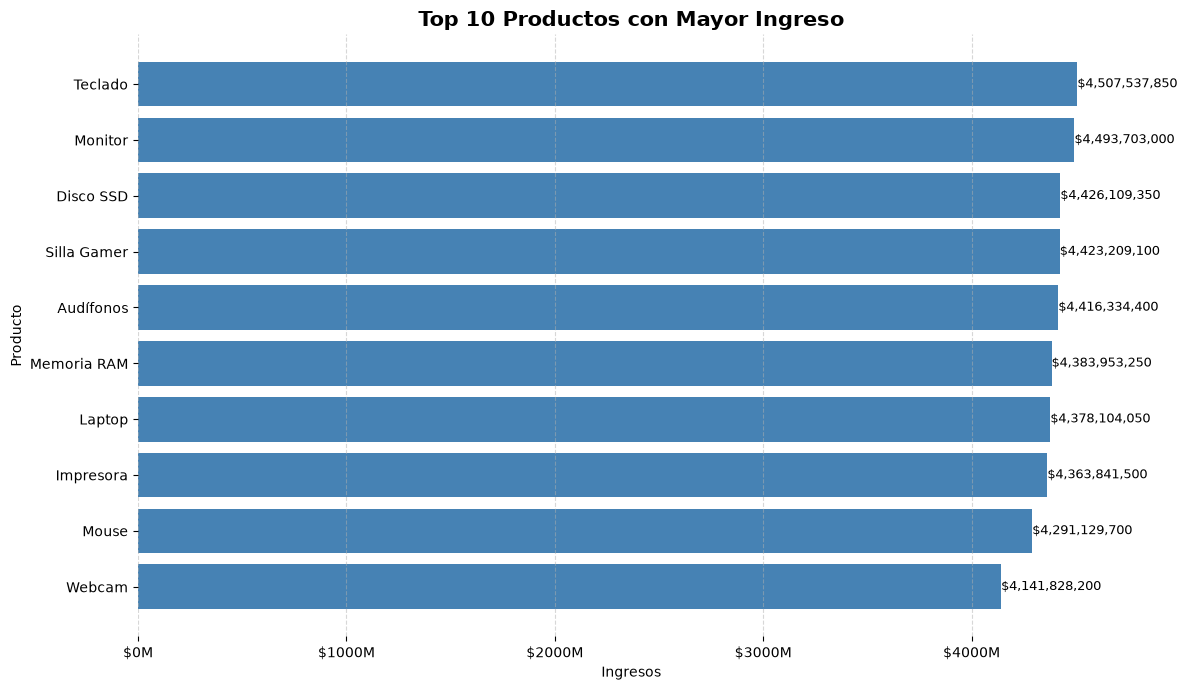

In [4]:
from matplotlib.ticker import FuncFormatter

ventas_producto = (
    df.groupby("Producto")["Total Venta"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,7))

plt.barh(
    ventas_producto.index,
    ventas_producto.values,
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 Productos con Mayor Ingreso",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Ingresos")
plt.ylabel("Producto")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

for i, valor in enumerate(ventas_producto.values):
    plt.text(
        valor,
        i,
        f"${valor:,.0f}",
        va="center",
        fontsize=9
    )

plt.box(False)

plt.tight_layout()
plt.show()

### Interpretación

La gráfica muestra varias cosas, la primera y la más notable es que el producto que ha generado más ventas ha sido el teclado, seguido de los monitores y los discos SSD, además de que se muestra una excelente distribución de ventas ya que la diferencia entre el producto más vendido y el menos vendido es mínima. Se sugiere analizar qué características tienen a mejorar los 3 productos que generaron menor número de ventas, como por ejemplo, la impresora simplemente hace fotocopias e imprime, sin embargo, las personas necesitan una que también tenga funcionalidades de escaneo. Los modelos de mouse son bastante antiguos en comparación a la competencia, sin embargo se puede incrementar la venta de esta categoría si se hace un stock de este producto más reciente y con precios competitivos con respecto a la competencia, además de que las webcam se podrían seguir vendiendo pero normalmente, las personas prefieren laptops con webcam integrada, la única forma en la que alguien con un pc de mesa compre una webcam, es que quiera sacarle el jugo a su equipo, ahí es donde entran las cámaras profesionales de video, portables y accesibles para todos.

In [6]:
ventas_ciudad = (
    df.groupby("Ciudad")["Total Venta"]
      .sum()
      .sort_values()
)

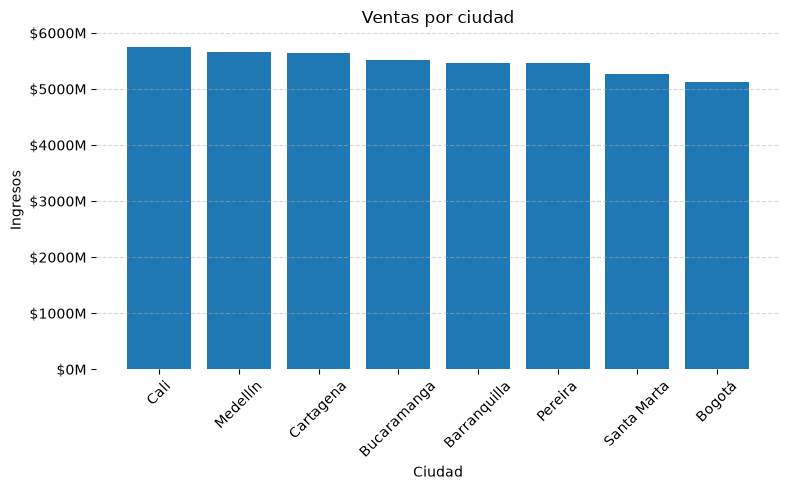

In [22]:
plt.figure(figsize=(8,5))

plt.bar(
    ventas_ciudad.index,
    ventas_ciudad.values
)

plt.gca().invert_xaxis()

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"${y/1_000_000:.0f}M")
)

plt.title("Ventas por ciudad")

plt.xlabel("Ciudad")

plt.ylabel("Ingresos")

plt.xticks(rotation=45)

plt.box(False)

plt.tight_layout()

plt.show()

# Interpretación

Se observa que algunas ciudades concentran una mayor participación en las ventas.

Este análisis ayuda a identificar mercados prioritarios y posibles oportunidades de crecimiento en ciudades con menor desempeño.

In [10]:
ventas_categoria = (
    df.groupby("Categoría")["Total Venta"]
      .sum()
      .sort_values(ascending=False)
)

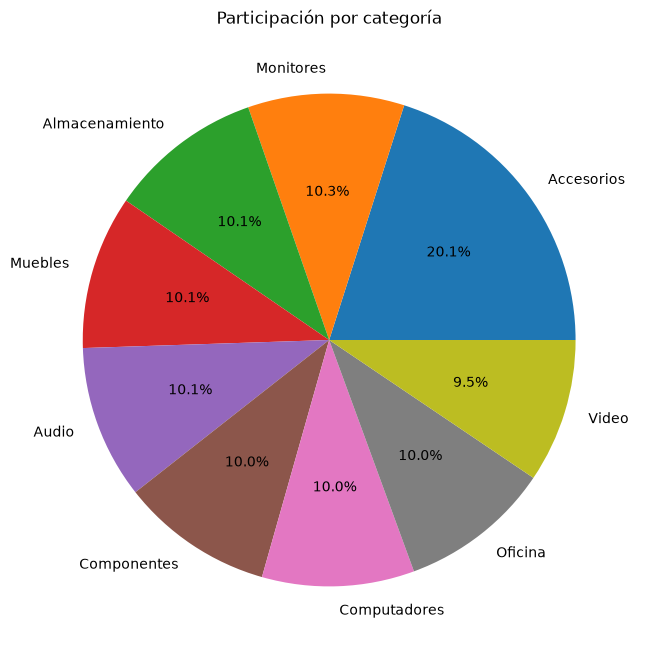

In [11]:
plt.figure(figsize=(8,8))

plt.pie(
    ventas_categoria,
    labels=ventas_categoria.index,
    autopct="%1.1f%%"
)

plt.title("Participación por categoría")

plt.show()

# Interpretación

La distribución porcentual permite identificar cuáles categorías generan la mayor proporción de ingresos del negocio, facilitando la toma de decisiones sobre inversión y abastecimiento.

In [12]:
metodos = df["Método Pago"].value_counts()

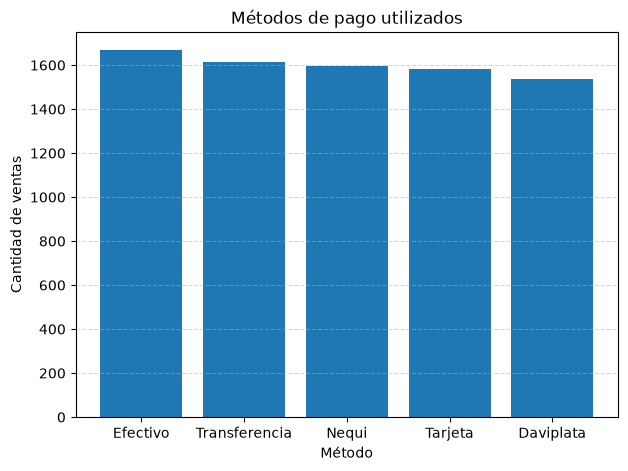

In [24]:
plt.figure(figsize=(7,5))

plt.bar(
    metodos.index,
    metodos.values
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.title("Métodos de pago utilizados")

plt.xlabel("Método")

plt.ylabel("Cantidad de ventas")

plt.show()

# Interpretación

El método de pago más utilizado refleja la preferencia de los clientes y puede servir para optimizar procesos de pago o establecer alianzas con entidades financieras.

In [ ]:
df["Fecha"] = pd.to_datetime(df["Fecha"])

df["AñoMes"] = df["Fecha"].dt.to_period("M")

ventas_mes = (
    df.groupby("AñoMes")["Total Venta"]
      .sum()
      .sort_index()
)

ventas_mes.index = ventas_mes.index.astype(str)



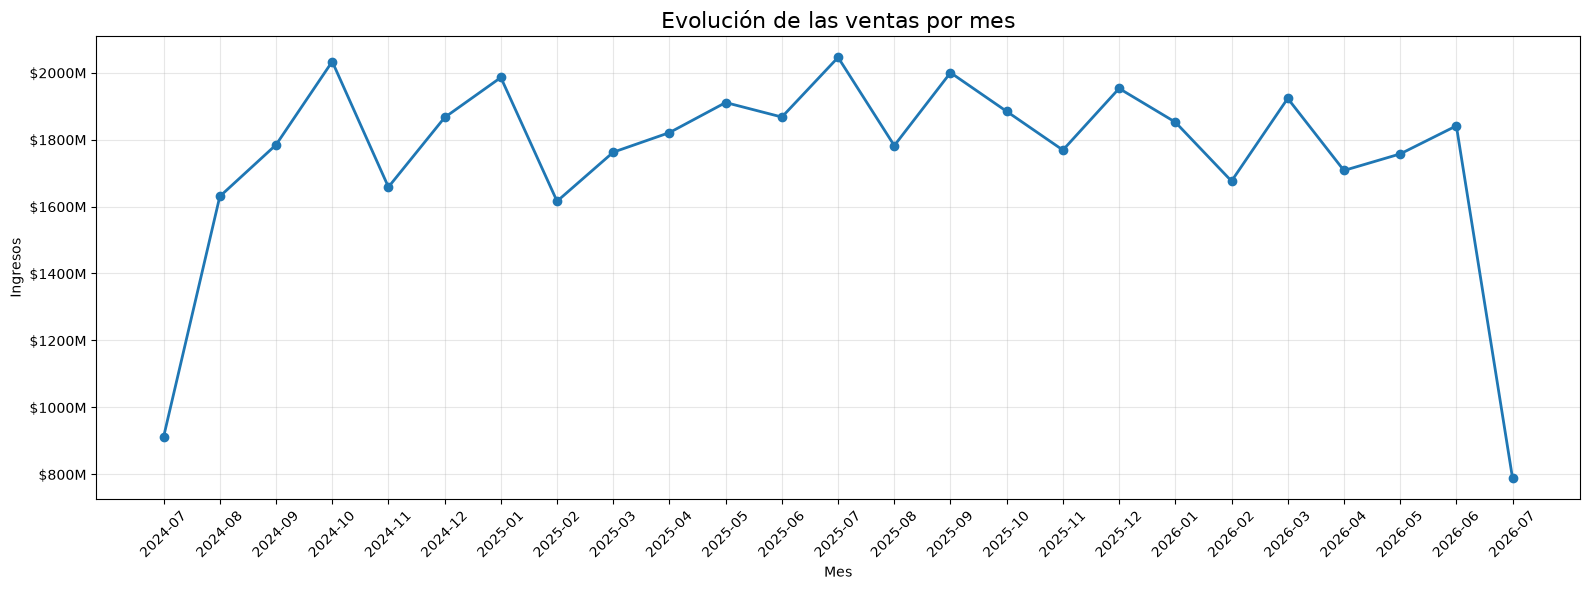

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    ventas_mes.index,
    ventas_mes.values,
    marker="o",
    linewidth=2
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"${y/1_000_000:.0f}M")
)

plt.title("Evolución de las ventas por mes", fontsize=16)

plt.xlabel("Mes")

plt.ylabel("Ingresos")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Interpretación

La evolución anual permite identificar tendencias de crecimiento o disminución en las ventas, facilitando la evaluación del desempeño del negocio a lo largo del tiempo.